# CatBoost v2

LightGBM v1 не выполнила бизнес-условие на новых данных. Теперь фактические ответы за февраль и март уже известны, поэтому добавляю их к истории и обучаю CatBoost.

Апрель оставляю для последней проверки перед новой выкладкой.

## 1. Собираем доступную историю

In [1]:
import json
from pathlib import Path

from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

train = pd.read_parquet(
    "../data/processed/train.parquet"
)

validation = pd.read_parquet(
    "../data/processed/validation.parquet"
)

test = pd.read_parquet(
    "../data/processed/test.parquet"
)

for data in [train, validation, test]:
    data["booking_date"] = pd.to_datetime(
        data["booking_date"]
    )

### Последний месяц test оставляем для проверки

In [2]:
history = pd.concat(
    [train, validation, test],
    ignore_index=True
).sort_values("booking_date")

catboost_train = history[
    history["booking_date"] < "2017-04-01"
].copy()

april = history[
    (history["booking_date"] >= "2017-04-01")
    & (history["booking_date"] < "2017-05-01")
].copy()

In [3]:
pd.DataFrame({
    "rows": [len(catboost_train), len(april)],
    "date_from": [
        catboost_train["booking_date"].min(),
        april["booking_date"].min(),
    ],
    "date_to": [
        catboost_train["booking_date"].max(),
        april["booking_date"].max(),
    ],
    "cancellation_rate": [
        catboost_train["is_canceled"].mean(),
        april["is_canceled"].mean(),
    ],
}, index=["train", "april"])

,rows,date_from,date_to,cancellation_rate
train,110075,2013-06-24,2017-03-31,0.377933
april,2736,2017-04-01,2017-04-30,0.311404


Апрель уже участвовал в общей диагностике LightGBM, поэтому это не полностью неизвестный test. Здесь он используется как предвыкладочная validation для новой модели.

Настоящим независимым периодом для CatBoost остаются май–август: их я ещё не открываю.

## 2. Готовим данные для CatBoost

In [4]:
target = "is_canceled"

drop_cols = [
    target,
    "booking_date",
    "arrival_date",
]

X_train = catboost_train.drop(columns=drop_cols)
y_train = catboost_train[target]

X_april = april.drop(columns=drop_cols)
y_april = april[target]

В LightGBM категории кодировались через One-Hot Encoding. Здесь оставляю их обычными строками и передаю CatBoost список категориальных колонок.

In [5]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in categorical_cols:
    X_train[col] = (
        X_train[col]
        .astype("string")
        .fillna("Missing")
    )

    X_april[col] = (
        X_april[col]
        .astype("string")
        .fillna("Missing")
    )

categorical_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'agent',
 'company',
 'customer_type',
 'country_group']

## 3. Обучаем модель

Параметры беру из tuning на старой validation. По апрелю их не перебираю — иначе подгонимся под контрольный месяц.

In [6]:
catboost_params = {
    "iterations": 436,
    "learning_rate": 0.04,
    "depth": 8,
    "l2_leaf_reg": 1,
    "random_strength": 0,
    "bagging_temperature": 1,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False,
}

model = CatBoostClassifier(**catboost_params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

CatBoostClassifier(allow_writing_files=False, bagging_temperature=1, depth=8, eval_metric='AUC', iterations=436, l2_leaf_reg=1, learning_rate=0.04, loss_function='Logloss', random_seed=42, random_strength=0, verbose=False)

### Проверяем ранжирование на апреле

In [7]:
april_proba = model.predict_proba(X_april)[:, 1]

pd.Series({
    "roc_auc": roc_auc_score(y_april, april_proba),
    "pr_auc": average_precision_score(y_april, april_proba),
}).round(4)

roc_auc    0.8732
pr_auc     0.7434
dtype: float64

## 4. Подбираем рабочий порог

Правило то же, что у LightGBM: `Precision >= 0.70`, затем максимальный `Recall`.

In [8]:
precision, recall, thresholds = precision_recall_curve(
    y_april,
    april_proba
)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

candidates = threshold_table[
    threshold_table["precision"] >= 0.70
]

best_row = (
    candidates
    .sort_values(
        ["recall", "precision"],
        ascending=False
    )
    .iloc[0]
)

threshold = float(best_row["threshold"])

best_row

threshold    0.405667
precision    0.707246
recall       0.572770
Name: 1894, dtype: float64

### Метрики на выбранном пороге

In [9]:
april_pred = (
    april_proba >= threshold
).astype(int)

april_metrics = pd.Series({
    "precision": precision_score(y_april, april_pred),
    "recall": recall_score(y_april, april_pred),
    "f1": f1_score(y_april, april_pred),
    "roc_auc": roc_auc_score(y_april, april_proba),
    "pr_auc": average_precision_score(y_april, april_proba),
})

april_metrics.round(4)

precision    0.7072
recall       0.5728
f1           0.6329
roc_auc      0.8732
pr_auc       0.7434
dtype: float64

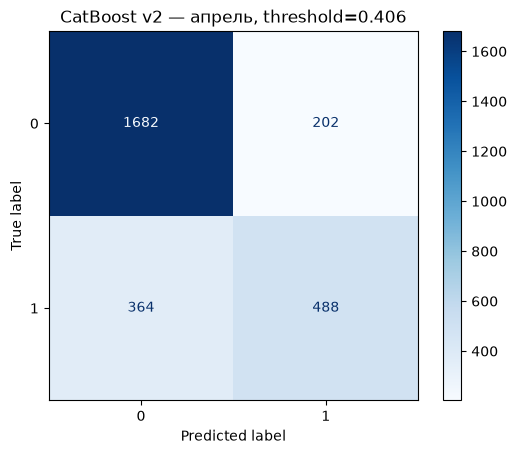

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_april,
    april_pred,
    cmap="Blues"
)

plt.title(
    f"CatBoost v2 — апрель, threshold={threshold:.3f}"
)
plt.show()

## Вывод

На апреле CatBoost выполняет бизнес-условие: `Precision` около 0.71. При этом модель находит примерно 57% отмен. Recall ниже, чем был у LightGBM на старой validation, но список срабатываний снова достаточно точный для работы менеджеров.

Эту модель и threshold фиксирую как CatBoost v2. Дальше ничего не меняю по результатам мая–августа.

## 5. Сохраняем production-модель

In [11]:
Path("../models").mkdir(parents=True, exist_ok=True)

model.save_model(
    "../models/catboost_v2.cbm"
)

model_metadata = {
    "model": "CatBoost",
    "version": "v2",
    "threshold": threshold,
    "feature_cols": X_train.columns.tolist(),
    "categorical_cols": categorical_cols,
    "trained_until": "2017-03-31",
    "validation_period": "2017-04",
}

with open(
    "../models/model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4,
        ensure_ascii=False
    )